### Trends Analysis
##### Images from prior_vis_month, sf_vis_month, k_vis_month, post_vis_month, sector_vis_month, concentration_vis_month
##### CSV from concentration_csv_month, sector_csv_month, emissions_month, errors_month

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates

In [7]:
full_vars = [
    "wetlands",
    "livestock",
    "oil",
    "gas",
    "rice",
    "landfills",
    "coal",
    "wastewater",
    "otherna",
    "otheranth",
    "lake",
]

In [ ]:
# selected_rows

,date,prior,posterior,DOFS
8,2018,4.199091,5.227776,23.317420
21,2019,4.200693,7.395317,31.757458
34,2020,4.200693,6.696752,31.884647
47,2021,4.200693,7.321705,36.033210
60,2022,4.200693,7.732902,36.357010
65,2023,4.294216,7.267610,15.114243


#### Yearly Total Methane Emissions

<Figure size 1000x600 with 0 Axes>

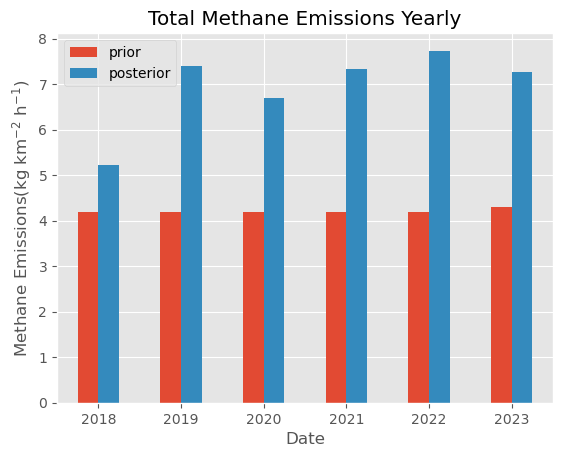

In [ ]:
emis_month = pd.read_csv("emissions_month.csv")

selected_rows = emis_month.iloc[[8, 21, 34, 47, 60, 65]]

plt.figure(figsize=(10, 6))
plt.style.use("ggplot")
selected_rows.plot(x="date", y=["prior", "posterior"], kind="bar", rot=0)
plt.legend(["prior", "posterior"])
plt.title("Total Methane Emissions Yearly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")

plt.show()

#### Monthly Total Methane Emissions

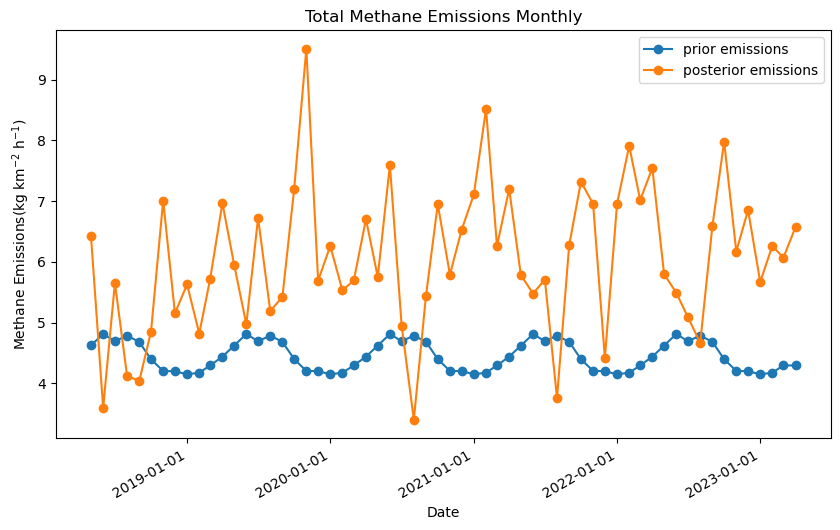

In [ ]:
emis_month = pd.read_csv("emissions_month.csv", skiprows=[9, 22, 35, 48, 61, 66])

# emis_month['Date'] = pd.to_datetime(emis_month['date'])
# emis_month.set_index('Date', inplace=True)

plt.figure(figsize=(10, 6))
# plt.plot(emis_month['prior'], label='prior emissions', marker='o')
# plt.plot(emis_month['posterior'], label='posterior emissions', marker='o')

dates = [datetime.datetime.strptime(str(date), "%Y%m") for date in emis_month["date"]]

plt.plot_date(dates, emis_month["prior"], linestyle="solid", label="prior emissions")
plt.plot_date(
    dates, emis_month["posterior"], linestyle="solid", label="posterior emissions"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.gcf().autofmt_xdate()

plt.title("Total Methane Emissions Monthly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")
plt.legend()
plt.show()

### Yearly Sector-based Methane Emissions

In [ ]:
#
wetlands_pri_T, wetlands_pri_err_T, wetlands_post_T, wetlands_post_err_T = (
    [],
    [],
    [],
    [],
)
livestock_pri_T, livestock_pri_err_T, livestock_post_T, livestock_post_err_T = (
    [],
    [],
    [],
    [],
)
oil_pri_T, oil_pri_err_T, oil_post_T, oil_post_err_T = [], [], [], []
gas_pri_T, gas_pri_err_T, gas_post_T, gas_post_err_T = [], [], [], []
rice_pri_T, rice_pri_err_T, rice_post_T, rice_post_err_T = [], [], [], []
landfills_pri_T, landfills_pri_err_T, landfills_post_T, landfills_post_err_T = (
    [],
    [],
    [],
    [],
)
coal_pri_T, coal_pri_err_T, coal_post_T, coal_post_err_T = [], [], [], []
wastewater_pri_T, wastewater_pri_err_T, wastewater_post_T, wastewater_post_err_T = (
    [],
    [],
    [],
    [],
)
otherna_pri_T, otherna_pri_err_T, otherna_post_T, otherna_post_err_T = [], [], [], []
otheranth_pri_T, otheranth_pri_err_T, otheranth_post_T, otheranth_post_err_T = (
    [],
    [],
    [],
    [],
)
lake_pri_T, lake_pri_err_T, lake_post_T, lake_post_err_T = [], [], [], []
total_pri_T, total_pri_err_T, total_post_T, total_post_err_T = [], [], [], []

for filename in os.listdir("./sector_csv_month/"):
    if filename.split("_")[1] != "T":
        continue
    sector_csv_month = pd.read_csv("./sector_csv_month/" + filename)
    wetlands_pri_T.append(sector_csv_month["za"][0])  # posterior
    wetlands_pri_err_T.append(sector_csv_month["za_err"][0])
    wetlands_post_T.append(sector_csv_month["zhat"][0])  # prior
    wetlands_post_err_T.append(sector_csv_month["zhat_err"][0])

    livestock_pri_T.append(sector_csv_month["za"][1])
    livestock_pri_err_T.append(sector_csv_month["za_err"][1])
    livestock_post_T.append(sector_csv_month["zhat"][1])
    livestock_post_err_T.append(sector_csv_month["zhat_err"][1])

    oil_pri_T.append(sector_csv_month["za"][2])
    oil_pri_err_T.append(sector_csv_month["za_err"][2])
    oil_post_T.append(sector_csv_month["zhat"][2])
    oil_post_err_T.append(sector_csv_month["zhat_err"][2])

    gas_pri_T.append(sector_csv_month["za"][3])
    gas_pri_err_T.append(sector_csv_month["za_err"][3])
    gas_post_T.append(sector_csv_month["zhat"][3])
    gas_post_err_T.append(sector_csv_month["zhat_err"][3])

    rice_pri_T.append(sector_csv_month["za"][4])
    rice_pri_err_T.append(sector_csv_month["za_err"][4])
    rice_post_T.append(sector_csv_month["zhat"][4])
    rice_post_err_T.append(sector_csv_month["zhat_err"][4])

    landfills_pri_T.append(sector_csv_month["za"][5])
    landfills_pri_err_T.append(sector_csv_month["za_err"][5])
    landfills_post_T.append(sector_csv_month["zhat"][5])
    landfills_post_err_T.append(sector_csv_month["zhat_err"][5])

    coal_pri_T.append(sector_csv_month["za"][6])
    coal_pri_err_T.append(sector_csv_month["za_err"][6])
    coal_post_T.append(sector_csv_month["zhat"][6])
    coal_post_err_T.append(sector_csv_month["zhat_err"][6])

    wastewater_pri_T.append(sector_csv_month["za"][7])
    wastewater_pri_err_T.append(sector_csv_month["za_err"][7])
    wastewater_post_T.append(sector_csv_month["zhat"][7])
    wastewater_post_err_T.append(sector_csv_month["zhat_err"][7])

    otherna_pri_T.append(sector_csv_month["za"][8])
    otherna_pri_err_T.append(sector_csv_month["za_err"][8])
    otherna_post_T.append(sector_csv_month["zhat"][8])
    otherna_post_err_T.append(sector_csv_month["zhat_err"][8])

    otheranth_pri_T.append(sector_csv_month["za"][9])
    otheranth_pri_err_T.append(sector_csv_month["za_err"][9])
    otheranth_post_T.append(sector_csv_month["zhat"][9])
    otheranth_post_err_T.append(sector_csv_month["zhat_err"][9])

    lake_pri_T.append(sector_csv_month["za"][10])
    lake_pri_err_T.append(sector_csv_month["za_err"][10])
    lake_post_T.append(sector_csv_month["zhat"][10])
    lake_post_err_T.append(sector_csv_month["zhat_err"][10])

    total_pri_T.append(sector_csv_month["za"][11])
    total_pri_err_T.append(sector_csv_month["za_err"][11])
    total_post_T.append(sector_csv_month["zhat"][11])
    total_post_err_T.append(sector_csv_month["zhat_err"][11])

/var/tmp/pbs.8580057.pbs/ipykernel_3063281/2778905202.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_rows['wetlands'] = wetlands_pri_T
/var/tmp/pbs.8580057.pbs/ipykernel_3063281/2778905202.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_rows['livestock'] = livestock_pri_T
/var/tmp/pbs.8580057.pbs/ipykernel_3063281/2778905202.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

<Figure size 1500x600 with 0 Axes>

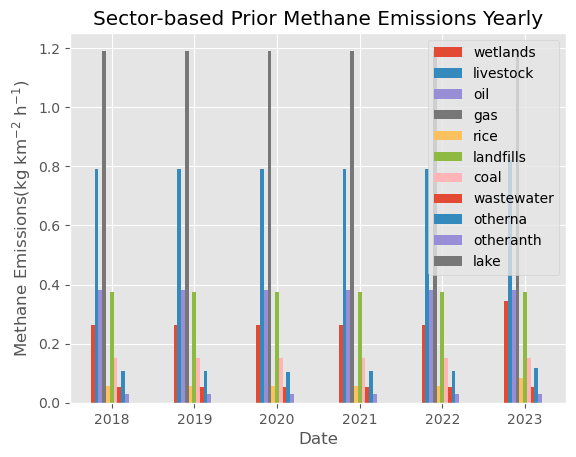

In [ ]:
emis_month = pd.read_csv("emissions_month.csv")

selected_rows = emis_month.iloc[[8, 21, 34, 47, 60, 65]]
selected_rows["wetlands"] = wetlands_pri_T
selected_rows["livestock"] = livestock_pri_T
selected_rows["oil"] = oil_pri_T
selected_rows["gas"] = gas_pri_T
selected_rows["rice"] = rice_pri_T
selected_rows["landfills"] = landfills_pri_T
selected_rows["coal"] = coal_pri_T
selected_rows["wastewater"] = wastewater_pri_T
selected_rows["otherna"] = otherna_pri_T
selected_rows["otheranth"] = otheranth_pri_T
selected_rows["lake"] = lake_pri_T
# selected_rows['total'] = total_pri_T

plt.figure(figsize=(15, 6))
plt.style.use("ggplot")
selected_rows.plot(
    x="date",
    y=[
        "wetlands",
        "livestock",
        "oil",
        "gas",
        "rice",
        "landfills",
        "coal",
        "wastewater",
        "otherna",
        "otheranth",
        "lake",
    ],
    kind="bar",
    rot=0,
)
plt.legend(
    [
        "wetlands",
        "livestock",
        "oil",
        "gas",
        "rice",
        "landfills",
        "coal",
        "wastewater",
        "otherna",
        "otheranth",
        "lake",
    ],
    loc="upper right",
)
plt.title("Sector-based Prior Methane Emissions Yearly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")
plt.show()

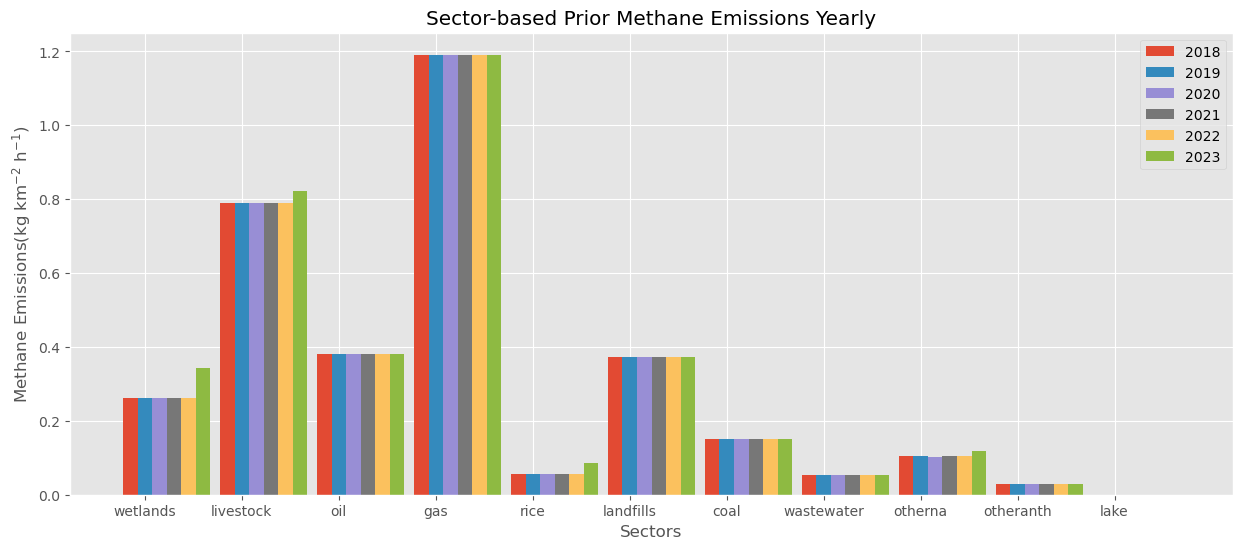

In [ ]:
#
categories = [
    "wetlands",
    "livestock",
    "oil",
    "gas",
    "rice",
    "landfills",
    "coal",
    "wastewater",
    "otherna",
    "otheranth",
    "lake",
]
values0 = np.array(selected_rows.iloc[0][4:])
values1 = np.array(selected_rows.iloc[1][4:])
values2 = np.array(selected_rows.iloc[2][4:])
values3 = np.array(selected_rows.iloc[3][4:])
values4 = np.array(selected_rows.iloc[4][4:])
values5 = np.array(selected_rows.iloc[5][4:])

plt.figure(figsize=(15, 6))
plt.style.use("ggplot")

bar_width = 0.15
index = np.arange(len(categories))

plt.bar(index, values0, width=bar_width, label="2018")
plt.bar(index + bar_width, values1, width=bar_width, label="2019")
plt.bar(index + 2 * bar_width, values2, width=bar_width, label="2020")
plt.bar(index + 3 * bar_width, values3, width=bar_width, label="2021")
plt.bar(index + 4 * bar_width, values4, width=bar_width, label="2022")
plt.bar(index + 5 * bar_width, values5, width=bar_width, label="2023")

plt.xlabel("Sectors")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")

plt.xticks(index + bar_width, categories)

plt.legend()

plt.title("Sector-based Prior Methane Emissions Yearly")
plt.show()

/var/tmp/pbs.8580057.pbs/ipykernel_3063281/2481205985.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_rows['wetlands'] = wetlands_post_T
/var/tmp/pbs.8580057.pbs/ipykernel_3063281/2481205985.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_rows['livestock'] = livestock_post_T
/var/tmp/pbs.8580057.pbs/ipykernel_3063281/2481205985.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

<Figure size 2000x600 with 0 Axes>

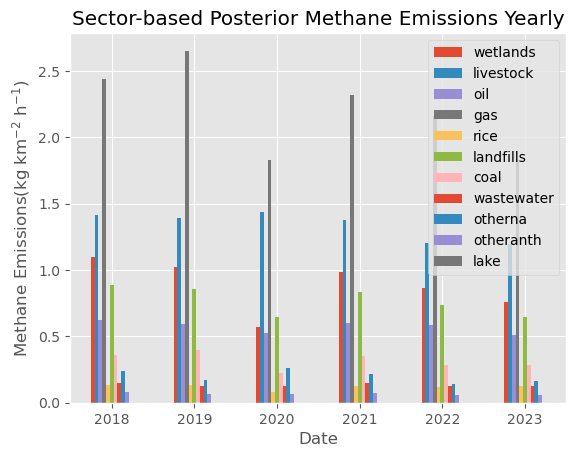

In [ ]:
emis_month = pd.read_csv("emissions_month.csv")

selected_rows = emis_month.iloc[[8, 21, 34, 47, 60, 65]]
selected_rows["wetlands"] = wetlands_post_T
selected_rows["livestock"] = livestock_post_T
selected_rows["oil"] = oil_post_T
selected_rows["gas"] = gas_post_T
selected_rows["rice"] = rice_post_T
selected_rows["landfills"] = landfills_post_T
selected_rows["coal"] = coal_post_T
selected_rows["wastewater"] = wastewater_post_T
selected_rows["otherna"] = otherna_post_T
selected_rows["otheranth"] = otheranth_post_T
selected_rows["lake"] = lake_post_T
# selected_rows['total'] = total_post_T

plt.figure(figsize=(20, 6))
plt.style.use("ggplot")
selected_rows.plot(
    x="date",
    y=[
        "wetlands",
        "livestock",
        "oil",
        "gas",
        "rice",
        "landfills",
        "coal",
        "wastewater",
        "otherna",
        "otheranth",
        "lake",
    ],
    kind="bar",
    rot=0,
)
plt.legend(
    [
        "wetlands",
        "livestock",
        "oil",
        "gas",
        "rice",
        "landfills",
        "coal",
        "wastewater",
        "otherna",
        "otheranth",
        "lake",
    ],
    loc="upper right",
)
plt.title("Sector-based Posterior Methane Emissions Yearly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")
plt.show()

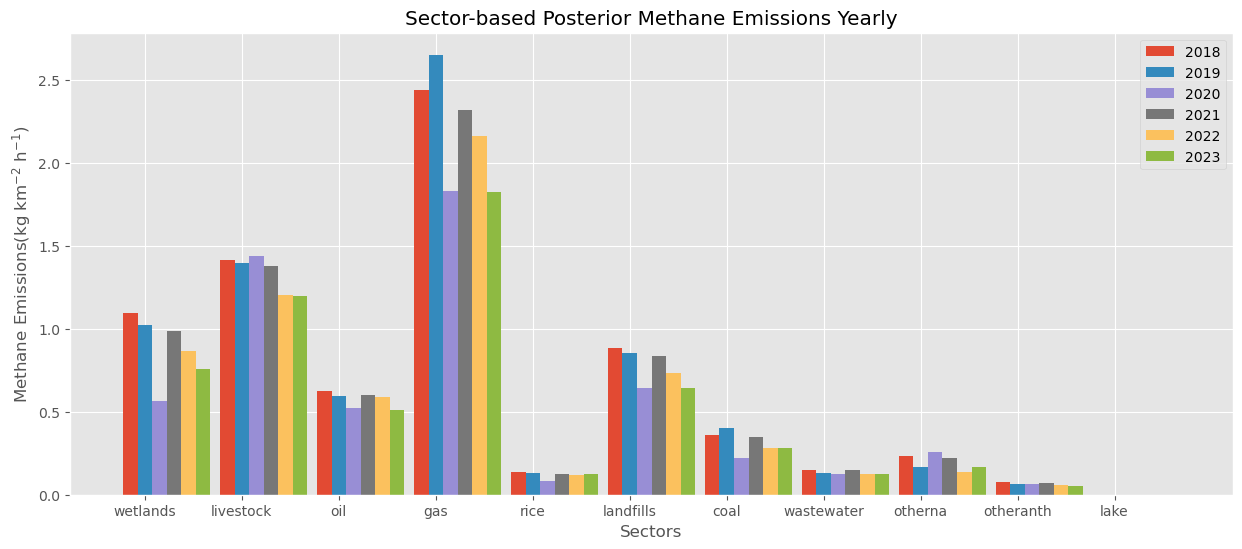

In [ ]:
#
categories = [
    "wetlands",
    "livestock",
    "oil",
    "gas",
    "rice",
    "landfills",
    "coal",
    "wastewater",
    "otherna",
    "otheranth",
    "lake",
]
values0 = np.array(selected_rows.iloc[0][4:])
values1 = np.array(selected_rows.iloc[1][4:])
values2 = np.array(selected_rows.iloc[2][4:])
values3 = np.array(selected_rows.iloc[3][4:])
values4 = np.array(selected_rows.iloc[4][4:])
values5 = np.array(selected_rows.iloc[5][4:])

plt.figure(figsize=(15, 6))
plt.style.use("ggplot")
bar_width = 0.15
index = np.arange(len(categories))

plt.bar(index, values0, width=bar_width, label="2018")
plt.bar(index + bar_width, values1, width=bar_width, label="2019")
plt.bar(index + 2 * bar_width, values2, width=bar_width, label="2020")
plt.bar(index + 3 * bar_width, values3, width=bar_width, label="2021")
plt.bar(index + 4 * bar_width, values4, width=bar_width, label="2022")
plt.bar(index + 5 * bar_width, values5, width=bar_width, label="2023")

plt.xlabel("Sectors")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")
plt.xticks(index + bar_width, categories)
plt.legend()
plt.title("Sector-based Posterior Methane Emissions Yearly")
plt.show()

### Monthly Sector-based Methane Emissions

In [125]:
wetlands_pri, wetlands_pri_err, wetlands_post, wetlands_post_err = [], [], [], []
livestock_pri, livestock_pri_err, livestock_post, livestock_post_err = [], [], [], []
oil_pri, oil_pri_err, oil_post, oil_post_err = [], [], [], []
gas_pri, gas_pri_err, gas_post, gas_post_err = [], [], [], []
rice_pri, rice_pri_err, rice_post, rice_post_err = [], [], [], []
landfills_pri, landfills_pri_err, landfills_post, landfills_post_err = [], [], [], []
coal_pri, coal_pri_err, coal_post, coal_post_err = [], [], [], []
wastewater_pri, wastewater_pri_err, wastewater_post, wastewater_post_err = (
    [],
    [],
    [],
    [],
)
otherna_pri, otherna_pri_err, otherna_post, otherna_post_err = [], [], [], []
otheranth_pri, otheranth_pri_err, otheranth_post, otheranth_post_err = [], [], [], []
lake_pri, lake_pri_err, lake_post, lake_post_err = [], [], [], []
total_pri, total_pri_err, total_post, total_post_err = [], [], [], []

for filename in os.listdir("./sector_csv_month/"):
    if filename.split("_")[1] != "month":
        continue
    sector_csv_month = pd.read_csv("./sector_csv_month/" + filename)
    wetlands_pri.append(sector_csv_month["za"][0])  # posterior
    wetlands_pri_err.append(sector_csv_month["za_err"][0])
    wetlands_post.append(sector_csv_month["zhat"][0])  # prior
    wetlands_post_err.append(sector_csv_month["zhat_err"][0])

    if sector_csv_month["zhat"][1] > 3:
        print(filename)
    livestock_pri.append(sector_csv_month["za"][1])
    livestock_pri_err.append(sector_csv_month["za_err"][1])
    livestock_post.append(sector_csv_month["zhat"][1])
    livestock_post_err.append(sector_csv_month["zhat_err"][1])

    oil_pri.append(sector_csv_month["za"][2])
    oil_pri_err.append(sector_csv_month["za_err"][2])
    oil_post.append(sector_csv_month["zhat"][2])
    oil_post_err.append(sector_csv_month["zhat_err"][2])

    gas_pri.append(sector_csv_month["za"][3])
    gas_pri_err.append(sector_csv_month["za_err"][3])
    gas_post.append(sector_csv_month["zhat"][3])
    gas_post_err.append(sector_csv_month["zhat_err"][3])

    rice_pri.append(sector_csv_month["za"][4])
    rice_pri_err.append(sector_csv_month["za_err"][4])
    rice_post.append(sector_csv_month["zhat"][4])
    rice_post_err.append(sector_csv_month["zhat_err"][4])

    landfills_pri.append(sector_csv_month["za"][5])
    landfills_pri_err.append(sector_csv_month["za_err"][5])
    landfills_post.append(sector_csv_month["zhat"][5])
    landfills_post_err.append(sector_csv_month["zhat_err"][5])

    coal_pri.append(sector_csv_month["za"][6])
    coal_pri_err.append(sector_csv_month["za_err"][6])
    coal_post.append(sector_csv_month["zhat"][6])
    coal_post_err.append(sector_csv_month["zhat_err"][6])

    wastewater_pri.append(sector_csv_month["za"][7])
    wastewater_pri_err.append(sector_csv_month["za_err"][7])
    wastewater_post.append(sector_csv_month["zhat"][7])
    wastewater_post_err.append(sector_csv_month["zhat_err"][7])

    otherna_pri.append(sector_csv_month["za"][8])
    otherna_pri_err.append(sector_csv_month["za_err"][8])
    otherna_post.append(sector_csv_month["zhat"][8])
    otherna_post_err.append(sector_csv_month["zhat_err"][8])

    otheranth_pri.append(sector_csv_month["za"][9])
    otheranth_pri_err.append(sector_csv_month["za_err"][9])
    otheranth_post.append(sector_csv_month["zhat"][9])
    otheranth_post_err.append(sector_csv_month["zhat_err"][9])

    lake_pri.append(sector_csv_month["za"][10])
    lake_pri_err.append(sector_csv_month["za_err"][10])
    lake_post.append(sector_csv_month["zhat"][10])
    lake_post_err.append(sector_csv_month["zhat_err"][10])

    total_pri.append(sector_csv_month["za"][11])
    total_pri_err.append(sector_csv_month["za_err"][11])
    total_post.append(sector_csv_month["zhat"][11])
    total_post_err.append(sector_csv_month["zhat_err"][11])

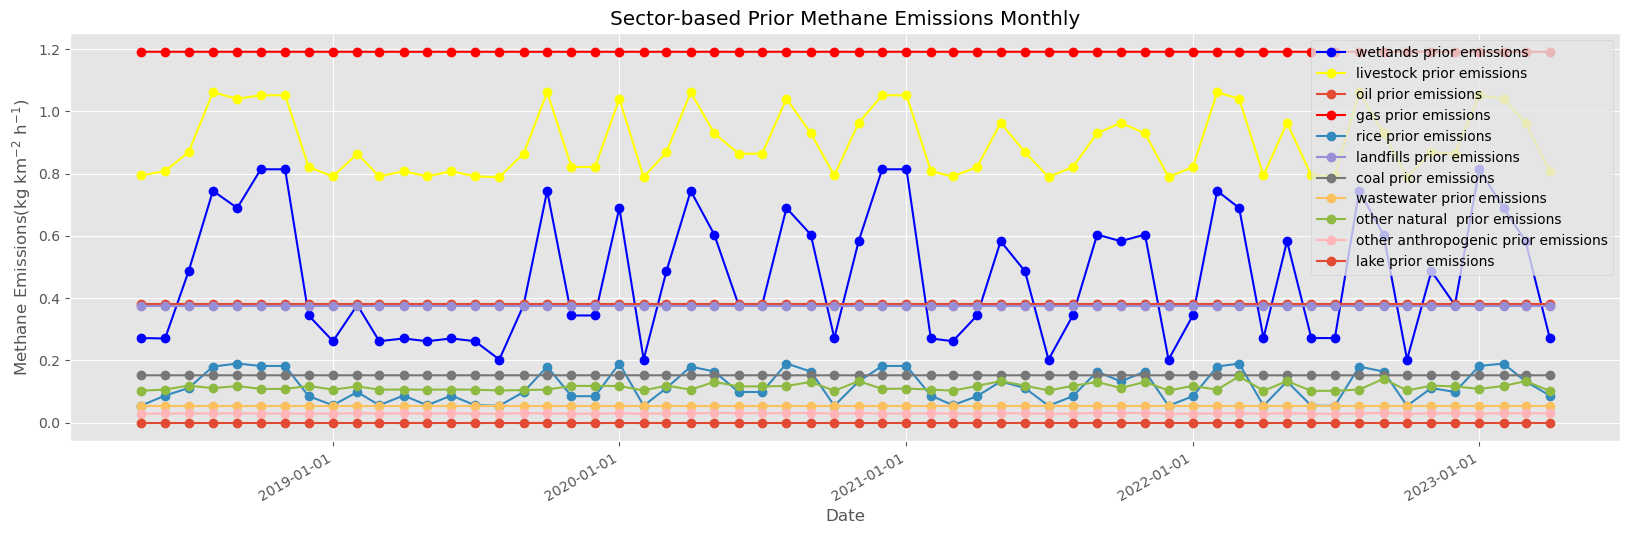

In [ ]:
emis_month = pd.read_csv("emissions_month.csv", skiprows=[9, 22, 35, 48, 61, 66])


def del_less(original_list):
    new_list = [max(0, x) for x in original_list]
    return new_list


plt.figure(figsize=(20, 6))
# plt.plot(emis_month['prior'], label='prior emissions', marker='o')
# plt.plot(emis_month['posterior'], label='posterior emissions', marker='o')

dates = [datetime.datetime.strptime(str(date), "%Y%m") for date in emis_month["date"]]

plt.plot_date(
    dates,
    del_less(wetlands_pri),
    linestyle="solid",
    label="wetlands prior emissions",
    color="blue",
)
plt.plot_date(
    dates,
    del_less(livestock_pri),
    linestyle="solid",
    label="livestock prior emissions",
    color="yellow",
)
plt.plot_date(dates, del_less(oil_pri), linestyle="solid", label="oil prior emissions")
plt.plot_date(
    dates,
    del_less(gas_pri),
    linestyle="solid",
    label="gas prior emissions",
    color="red",
)
plt.plot_date(
    dates, del_less(rice_pri), linestyle="solid", label="rice prior emissions"
)
plt.plot_date(
    dates, del_less(landfills_pri), linestyle="solid", label="landfills prior emissions"
)
plt.plot_date(
    dates, del_less(coal_pri), linestyle="solid", label="coal prior emissions"
)
plt.plot_date(
    dates,
    del_less(wastewater_pri),
    linestyle="solid",
    label="wastewater prior emissions",
)
plt.plot_date(
    dates,
    del_less(otherna_pri),
    linestyle="solid",
    label="other natural  prior emissions",
)
plt.plot_date(
    dates,
    del_less(otheranth_pri),
    linestyle="solid",
    label="other anthropogenic prior emissions",
)
plt.plot_date(
    dates, del_less(lake_pri), linestyle="solid", label="lake prior emissions"
)
# plt.plot_date(dates, del_less(total_pri), linestyle='solid', label='total prior emissions')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()
plt.title("Sector-based Prior Methane Emissions Monthly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")
plt.legend(loc="upper right")
plt.show()

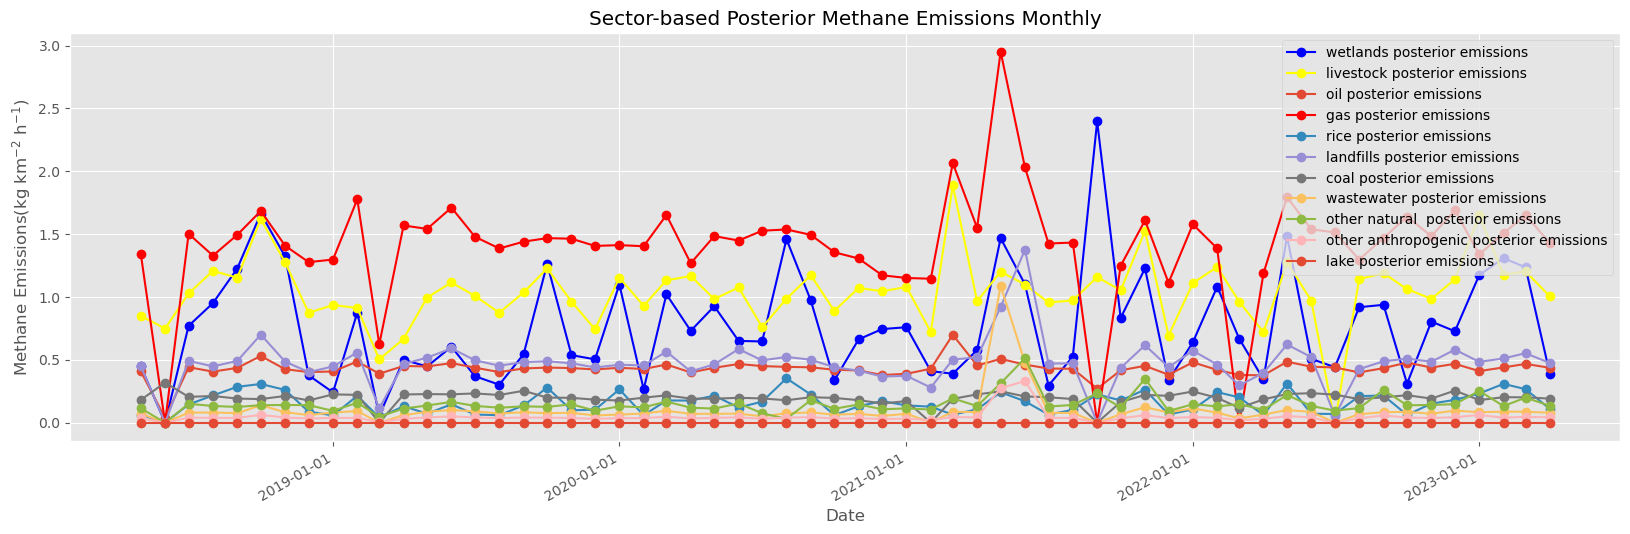

In [ ]:
emis_month = pd.read_csv("emissions_month.csv", skiprows=[9, 22, 35, 48, 61, 66])


def del_less(original_list):
    new_list = [max(0, x) for x in original_list]
    return new_list


plt.figure(figsize=(20, 6))
# plt.plot(emis_month['prior'], label='prior emissions', marker='o')
# plt.plot(emis_month['posterior'], label='posterior emissions', marker='o')

dates = [datetime.datetime.strptime(str(date), "%Y%m") for date in emis_month["date"]]
plt.plot_date(
    dates,
    del_less(wetlands_post),
    linestyle="solid",
    label="wetlands posterior emissions",
    color="blue",
)
plt.plot_date(
    dates,
    del_less(livestock_post),
    linestyle="solid",
    label="livestock posterior emissions",
    color="yellow",
)
plt.plot_date(
    dates, del_less(oil_post), linestyle="solid", label="oil posterior emissions"
)
plt.plot_date(
    dates,
    del_less(gas_post),
    linestyle="solid",
    label="gas posterior emissions",
    color="red",
)
plt.plot_date(
    dates, del_less(rice_post), linestyle="solid", label="rice posterior emissions"
)
plt.plot_date(
    dates,
    del_less(landfills_post),
    linestyle="solid",
    label="landfills posterior emissions",
)
plt.plot_date(
    dates, del_less(coal_post), linestyle="solid", label="coal posterior emissions"
)
plt.plot_date(
    dates,
    del_less(wastewater_post),
    linestyle="solid",
    label="wastewater posterior emissions",
)
plt.plot_date(
    dates,
    del_less(otherna_post),
    linestyle="solid",
    label="other natural  posterior emissions",
)
plt.plot_date(
    dates,
    del_less(otheranth_post),
    linestyle="solid",
    label="other anthropogenic posterior emissions",
)
plt.plot_date(
    dates, del_less(lake_post), linestyle="solid", label="lake posterior emissions"
)
# plt.plot_date(dates, del_less(total_post), linestyle='solid', label='total posterior emissions')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.gcf().autofmt_xdate()
plt.title("Sector-based Posterior Methane Emissions Monthly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
plt.ylabel("Methane Emissions(kg km$^{-2}$ h$^{-1}$)")
plt.legend(loc="upper right")
plt.show()

### ERROR

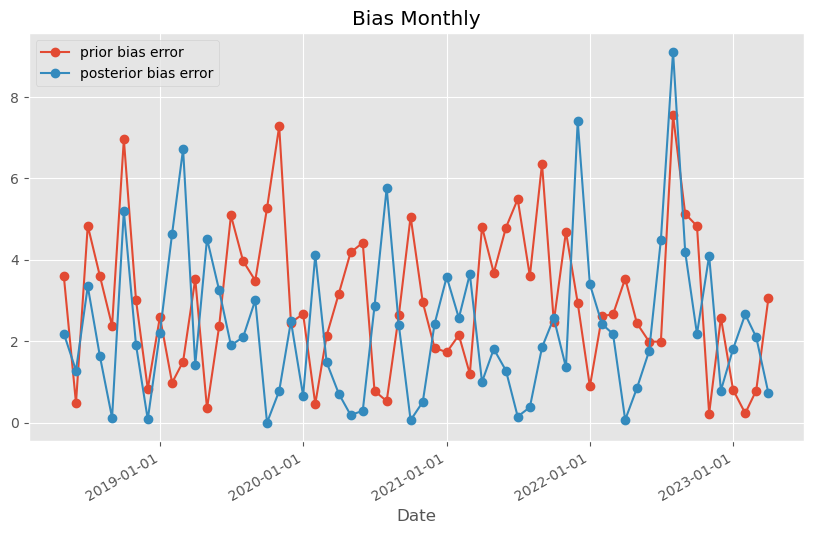

In [ ]:
err_month = pd.read_csv("errors_month.csv")

# emis_month['Date'] = pd.to_datetime(emis_month['date'])
# emis_month.set_index('Date', inplace=True)

plt.figure(figsize=(10, 6))
# plt.plot(emis_month['prior'], label='prior emissions', marker='o')
# plt.plot(emis_month['posterior'], label='posterior emissions', marker='o')

dates = [datetime.datetime.strptime(str(date), "%Y%m") for date in err_month["dates"]]
plt.plot_date(
    dates, np.abs(err_month["bias_prior"]), linestyle="solid", label="prior bias error"
)
plt.plot_date(
    dates,
    np.abs(err_month["bias_posterior"]),
    linestyle="solid",
    label="posterior bias error",
)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()
plt.title("Bias Monthly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
# plt.ylabel('Methane Emissions(kg km$^{-2}$ h$^{-1}$)')

plt.legend()
plt.show()

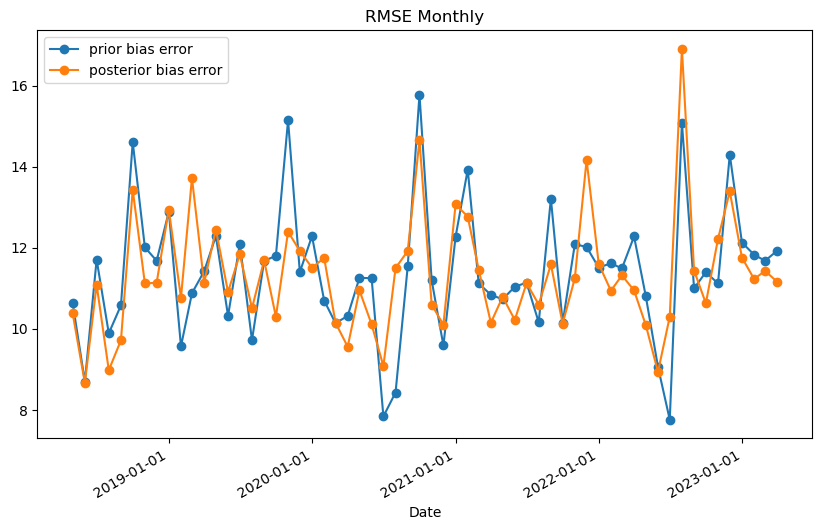

In [ ]:
err_month = pd.read_csv("errors_month.csv")

# emis_month['Date'] = pd.to_datetime(emis_month['date'])
# emis_month.set_index('Date', inplace=True)

plt.figure(figsize=(10, 6))
# plt.plot(emis_month['prior'], label='prior emissions', marker='o')
# plt.plot(emis_month['posterior'], label='posterior emissions', marker='o')

dates = [datetime.datetime.strptime(str(date), "%Y%m") for date in err_month["dates"]]

plt.plot_date(
    dates, err_month["RMSE_prior"], linestyle="solid", label="prior bias error"
)
plt.plot_date(
    dates, err_month["RMSE_posterior"], linestyle="solid", label="posterior bias error"
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

plt.title("RMSE Monthly")
# plt.xticks(emis_month['date'])
plt.xlabel("Date")
# plt.ylabel('Methane Emissions(kg km$^{-2}$ h$^{-1}$)')
plt.legend()
plt.show()